In [25]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv("/content/cleaned_data.csv")

In [27]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'text', 'text_clean', 'char_length', 'word_count',
       'avg_word_length', 'unique_word_ratio', 'type_encoded'],
      dtype='object')

In [28]:
X = df["text_clean"]
y = df["type"]

In [29]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,text,text_clean,char_length,word_count,avg_word_length,unique_word_ratio,type_encoded
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,...,NaN,NaN,NaN,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,wesentlicher sicherheitsvorfall sehr geehrtes ...,783,84,8.333333,0.869048,1
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,...,NaN,NaN,NaN,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support teamn...,563,84,5.714286,0.833333,1
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,...,NaN,NaN,NaN,Query About Smart Home System Integration Feat...,query about smart home system integration feat...,585,83,6.060241,0.819277,3
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,...,NaN,NaN,NaN,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...,639,95,5.736842,0.768421,3
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,...,NaN,NaN,NaN,Question About Marketing Agency Software Compa...,question about marketing agency software compa...,732,103,6.116505,0.776699,2


In [30]:
# Same split as baseline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
import os
from pathlib import Path

# Check current directory
print("📁 Current working directory:")
print(os.getcwd())

print("\n📂 Files in current directory:")
for item in os.listdir('.'):
    print(f"   {item}")

# Search for .pkl files
print("\n🔍 Searching for .pkl files...")
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.pkl'):
            full_path = os.path.join(root, file)
            print(f"   ✅ Found: {full_path}")

📁 Current working directory:
/content

📂 Files in current directory:
   .config
   best_model.pkl
   cleaned_data.csv
   sample_data

🔍 Searching for .pkl files...
   ✅ Found: ./best_model.pkl


In [32]:
import joblib

model = joblib.load("/content/best_model.pkl")
print(model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=20000, min_df=5,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model', LinearSVC(class_weight='balanced', random_state=42))])


In [33]:
import joblib

model = joblib.load("/content/best_model.pkl")

y_pred = model.predict(X_test)

In [44]:
import pandas as pd
y_test_encoded = y_test

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average="weighted")
recall = recall_score(y_test_encoded, y_pred, average="weighted")
f1 = f1_score(y_test_encoded, y_pred, average="weighted")

print("📊 Model Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

📊 Model Performance:
Accuracy : 0.8464
Precision: 0.8440
Recall   : 0.8464
F1 Score : 0.8449


In [45]:
print("="*80)
print("📊 OVERALL PERFORMANCE METRICS")
print("="*80)

# Calculate comprehensive metrics
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\n🎯 Overall Performance:")
print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • Precision (Macro): {precision_macro:.4f}")
print(f"   • Recall (Macro): {recall_macro:.4f}")
print(f"   • F1-Score (Macro): {f1_macro:.4f}")
print(f"   • F1-Score (Weighted): {f1_weighted:.4f}")

# Store metrics for later use
overall_metrics = {
    'Accuracy': accuracy,
    'Precision_Macro': precision_macro,
    'Recall_Macro': recall_macro,
    'F1_Macro': f1_macro,
    'F1_Weighted': f1_weighted
}

📊 OVERALL PERFORMANCE METRICS

🎯 Overall Performance:
   • Accuracy: 0.8464 (84.64%)
   • Precision (Macro): 0.8552
   • Recall (Macro): 0.8518
   • F1-Score (Macro): 0.8531
   • F1-Score (Weighted): 0.8449


In [47]:
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))


📋 Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       584
           1       0.80      0.84      0.82      2293
           2       0.66      0.61      0.64      1203
           3       0.99      0.99      0.99      1638

    accuracy                           0.85      5718
   macro avg       0.86      0.85      0.85      5718
weighted avg       0.84      0.85      0.84      5718



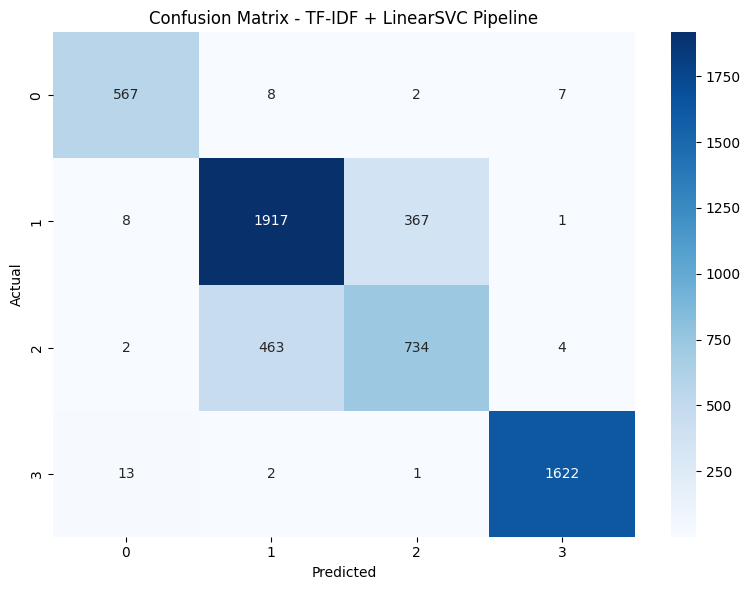

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - TF-IDF + LinearSVC Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("/content/confusion_matrix.png")
plt.show()

In [50]:
results = {
    "model": "TF-IDF + LinearSVC Pipeline",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

with open("/content/performance_metrics.json", "w") as f:
    json.dump(results, f, indent=4)

print("✅ Metrics saved successfully")

✅ Metrics saved successfully


In [51]:
sample_df = pd.DataFrame({
    "Text": X_test.values[:10],
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

sample_df

,Text,Actual,Predicted
0,potential data breach in healthcare system the...,1,1
1,hilfe zur entwicklung digitaler wachstumsmetho...,1,2
2,issue encountered assistance needed,2,1
3,bentigte untersttzung bei datenintegration ein...,1,1
4,anzeigeproblem fr projektmilestones das featur...,1,2
5,detailed information on billing options for sm...,3,3
6,enhanced security implement advanced security ...,0,0
7,problem mit datensicherheit ich mchte sie darb...,1,1
8,gert zur bildschirmaufnahme luft unregelmig ge...,1,1
9,enhanced security for medical data management ...,0,0


In [58]:
errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

errors = errors[errors["actual"] != errors["predicted"]]

errors.head(10)

,text,actual,predicted
26384,hilfe zur entwicklung digitaler wachstumsmetho...,1,2
1547,issue encountered assistance needed,2,1
25103,anzeigeproblem fr projektmilestones das featur...,1,2
15495,challenges in leadership for marketing agencie...,1,2
22073,problem with login on project platform a user ...,1,2
14150,facing connectivity problems with various prod...,1,2
22997,anomaly in data handling es gab eine datenverl...,2,1
3164,digital advertising campaign not meeting expec...,1,2
11195,geehrte kundenservice wir melden uns bezglich ...,2,1
10123,kundendienstliche anfrage die performance von ...,1,2
